<a href="https://colab.research.google.com/github/Drei-i/MachineLearningPIT/blob/main/ConfusionMatrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Rabaya(Burnout_DATASET) - Sheet1.csv to Rabaya(Burnout_DATASET) - Sheet1.csv


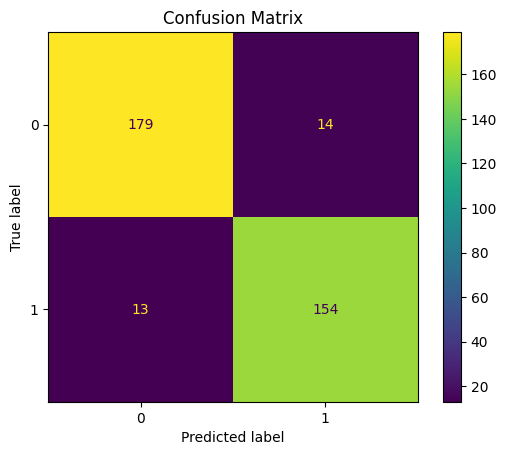

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load Dataset
from google.colab import files

# Upload Dataset Manually
uploaded = files.upload()

# Read Uploaded CSV File
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Convert Burnout Score into Classes
median_score = df['burnout_score'].median()
df['burnout_class'] = (df['burnout_score'] >= median_score).astype(int)

# Features and Target
X = df[[
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate'
]]

y = df['burnout_class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualization
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Confusion Matrix')
plt.show()